In [1]:
# environment setup using python virtual environments and pip package manager
%pip install pandas seaborn matplotlib numpy Ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Assignment 3  - CSI4142
Student names: Sameed Jafri (300253861), Jaime Bly (300231604)

work spilt:
- dataset 1: Jamie Bly
- dataset 2: Sameed Jafri



### Dataset 1
Description: Predicts house prices with a couple of binary features.

Dataset Name: Housing Prices Regression Dataset

Author: Compiled by Kaggle user Den_Kuznetz


Purpose: This is a real-world, non-synthetic dataset created to predict the price of real estate properties based on various features that influence the value of a property


Shape: The dataset contains exactly 500 rows and 12 columns.


Features and Descriptions 

ID: A unique identifier for each property.

Square_Feet: The area of the property in square meters.

Num_Bedrooms: The number of bedrooms in the property.

Num_Bathrooms: The number of bathrooms in the property.

Num_Floors: The number of floors in the property.

Year_Built: The year the property was built.

Has_Garden: Indicates whether the property has a garden (1 for yes, 0 for no).

Has_Pool: Indicates whether the property has a pool (1 for yes, 0 for no).

Garage_Size: The size of the garage in square meters.

Location_Score: A score from 0 to 10 indicating the quality of the neighborhood (higher scores indicate better neighborhoods).

Distance_to_Center: The distance from the property to the city center in kilometers.

Price: The target variable that represents the price of the property. This is the value we aim to predict.

Objective:
The goal of this task is to develop a regression model that predicts the Price of a real estate property using the other features as inputs. The model should be able to learn the relationship between these features and the price, providing an accurate prediction for unseen data.


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import sklearn.metrics
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold


# Set the path to the file you'd like to load
file_path = "real_estate_dataset.csv"

# Load the latest version
house_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "denkuznetz/housing-prices-regression",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", house_df.head())

c:\Users\djbly\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\djbly\AppData\Local\Temp\ipykernel_12552\1211763826.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  house_df = kagglehub.load_dataset(


First 5 records:    ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949            8.284019   
4           1         0           34        1.523278           14.648277   

           Price  
0  602134.816747  
1  591425.135386  
2  464478.696880  

In [3]:
#Validity Checks

# Checking uniqueness of ID
# Checker code to find uniqueness errors in the ID feature
# We use the duplicated() method. keep=False ensures we flag ALL instances of the duplicate, 
# not just the subsequent ones.
duplicate_mask = house_df.duplicated(subset=['ID'], keep=False)

# Extract the rows where the error was detected
detected_uniqueness_errors = house_df[duplicate_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_uniqueness_errors)} uniqueness errors.")
print("The automated check found multiple distinct rows sharing the exact same primary key (ID).")
print("\nExamples of the detected invalid data points (Notice the identical IDs):")

display(detected_uniqueness_errors[['ID']].head(3))



# For Square_Feet
# Checker code to find data type errors
# Attempting to convert the Square_Feet column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Square_Feet'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where an integer for minimum nights was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Square_Feet']].head(3))



# Num_Bedrooms
# Checker code to find range errors
# Filter the dataframe to find any rows where number of bedrooms is less than or equal to 0.
range_error_mask = house_df['Num_Bedrooms'] <= 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the number of rooms was logically impossible (less than or equal to zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Num_Bedrooms']].head(3))


# Num_Bathrooms
# Checker code to find range errors
# Filter the dataframe to find any rows where number of bathrooms is less than or equal to 0.
range_error_mask = house_df['Num_Bathrooms'] <= 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the number of bathrooms was logically impossible (less than or equal to zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Num_Bathrooms']].head(3))


# Num_Bedrooms
# Checker code to find range errors
# Filter the dataframe to find any rows where number of bedrooms is less than or equal to 0.
range_error_mask = house_df['Num_Floors'] <= 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the number of floors was logically impossible (less than or equal to zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Num_Bedrooms']].head(3))



# Year-Built
# Checker code to find data type errors
# Attempting to convert the column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Year_Built'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]
# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where an integer for minimum nights was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Year_Built']].head(3))

# Checker code to find range errors
# Filter the dataframe to find any rows where 'Year_Built' is greater than (assumed) year collected 
range_error_mask = house_df['Year_Built'] > 2022

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the nightly price was logically impossible (less than zero).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Year_Built']].head(3))



# Has_Pool
# Checker code to find look-up errors
# Define the accepted dictionary/look-up list
valid_has_pool_answers = [0, 1]

# Flag rows where the Has_Pool is NOT IN the valid list
lookup_error_mask = ~house_df['Has_Pool'].isin(valid_has_pool_answers)

# Extract the rows where the error was detected
detected_lookup_errors = house_df[lookup_error_mask]
# Report of findings
print(f"The validity checker successfully detected {len(detected_lookup_errors)} look-up errors.")
print("The automated check caught categorical values (3) that do not belong to the accepted answers for Has_Pool.")
print("\nExamples of the detected invalid data points:")

display(detected_lookup_errors[['ID', 'Has_Pool']].head(3))



# For Garage_Size
# Checker code to find data type errors
# Attempting to convert the Garage_Size column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Garage_Size'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center  was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Garage_Size']].head(3))

# For Distance_to_Center
# Checker code to find data type errors
# Attempting to convert the Distance_to_Center column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Distance_to_Center'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Garage_Size']].head(3))



# Location_Score
# Checker code to find range errors
# Filter the dataframe to find any rows where 'price' is less than 0
range_error_mask = house_df['Location_Score'] >= 10

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the Location_score is greater than the given range (greater than 10).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Location_Score']].head(3))
# Checker code to find range errors
# Filter the dataframe to find any rows where 'price' is less than 0
range_error_mask = house_df['Location_Score'] < 0

# Extract the rows where the error was detected
detected_range_errors = house_df[range_error_mask]
# Report of findings 
print(f"The validity checker successfully detected {len(detected_range_errors)} range errors.")
print("The automated check identified rows where the Location_score is less than the given range (less than 0).")
print("\nExamples of the detected invalid data points:")

display(detected_range_errors[['ID', 'Location_Score']].head(3))



#Price
# For Garage_Size
# Checker code to find data type errors
# Attempting to convert the Price column to numeric. Strings that fail conversion become NaN.
numeric_conversion = pd.to_numeric(house_df['Price'], errors='coerce')
invalid_type_mask = numeric_conversion.isna()

# Extract the rows where the error was detected
detected_type_errors = house_df[invalid_type_mask]

# Report of findings
print(f"The validity checker successfully detected {len(detected_type_errors)} data type errors.")
print("The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center  was expected.")
print("\nExamples of the detected invalid data points:")

# Displaying 3 examples of the corrupted data
display(detected_type_errors[['ID', 'Price']].head(3))

The validity checker successfully detected 0 uniqueness errors.
The automated check found multiple distinct rows sharing the exact same primary key (ID).

Examples of the detected invalid data points (Notice the identical IDs):


,ID


The validity checker successfully detected 0 data type errors.
The automated check identified rows containing non-numeric values ('invalid_string') where an integer for minimum nights was expected.

Examples of the detected invalid data points:


,ID,Square_Feet


The validity checker successfully detected 0 range errors.
The automated check identified rows where the number of rooms was logically impossible (less than or equal to zero).

Examples of the detected invalid data points:


...

,ID,Location_Score


The validity checker successfully detected 0 range errors.
The automated check identified rows where the Location_score is less than the given range (less than 0).

Examples of the detected invalid data points:


,ID,Location_Score


The validity checker successfully detected 0 data type errors.
The automated check identified rows containing non-numeric values ('invalid_string') where a float for Distance_to_Center  was expected.

Examples of the detected invalid data points:


,ID,Price


### Categorical feature encoding

Not necessary for this dataset, as it is all numerical features.

### Local Outlier 

As shown below, you can see how n_neighbors effects the number of outliers. Most of the outliers, except for 5, show that the outliers are on the ends of the price range. 
As such I will N=15 for this dataset, as it shows a good middle ground of eliminating potential outliers, while not removing potential useful data. For this data, I will remove them, as they essentially represent the edge cases, which absolutes that for the average example, they will have minimal effect. 

Total Number of Outliers at n_neighbors=5: 31


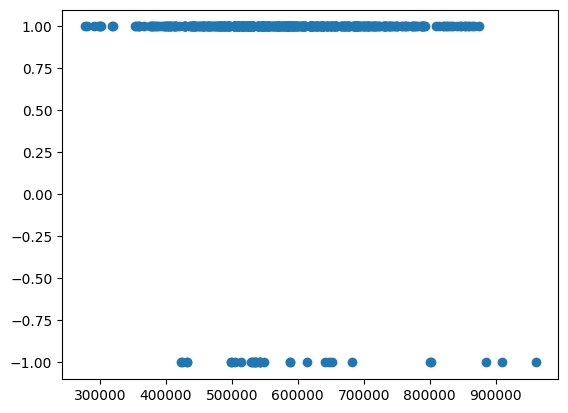

Total Number of Outliers at n_neighbors=10: 2


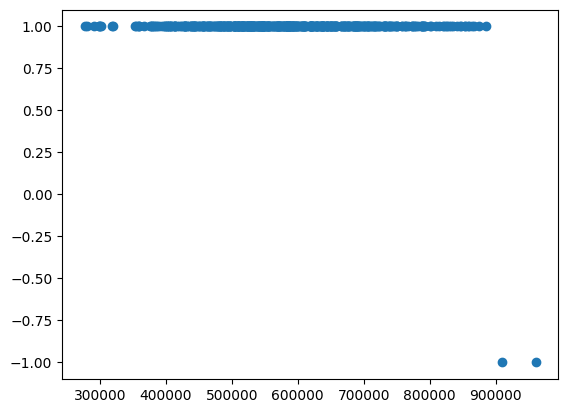

Total Number of Outliers at n_neighbors=20: 12


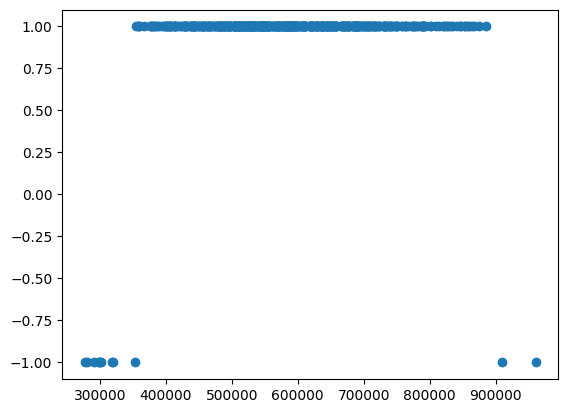

Total Number of Outliers at n_neighbors=30: 14


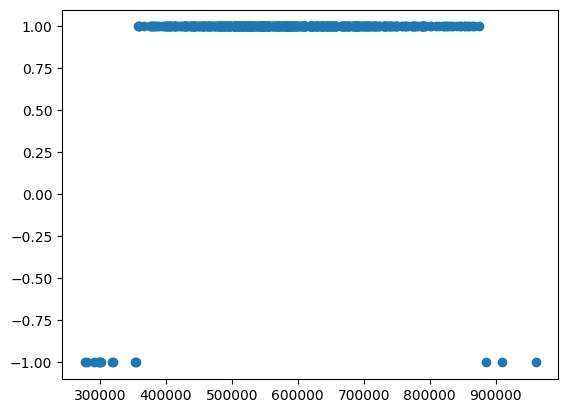

Total Number of Outliers at n_neighbors=15: 11


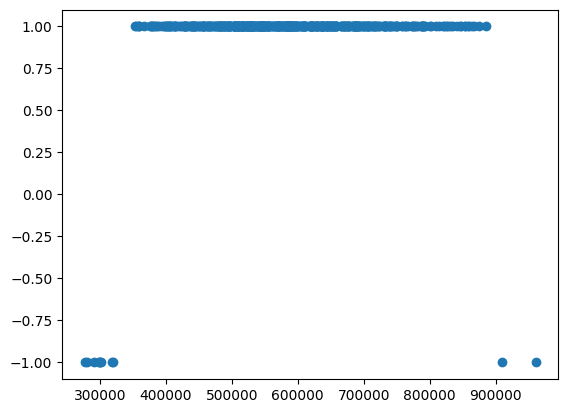

In [4]:
house_lof_5= LocalOutlierFactor(n_neighbors=5, contamination='auto')
house_lof_prediction = house_lof_5.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=5:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof_5= LocalOutlierFactor(n_neighbors=10, contamination='auto')
house_lof_prediction = house_lof_5.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=10:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof= LocalOutlierFactor(n_neighbors=20, contamination='auto')
house_lof_prediction = house_lof.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=20:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof= LocalOutlierFactor(n_neighbors=30, contamination='auto')
house_lof_prediction = house_lof.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=30:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()

house_lof= LocalOutlierFactor(n_neighbors=15, contamination='auto')
house_lof_prediction = house_lof.fit_predict(house_df)
print("Total Number of Outliers at n_neighbors=15:", (house_lof_prediction == -1).sum())
plt.scatter(house_df['Price'], house_lof_prediction)
plt.show()



In [5]:
#Removing outliers

outlier_house_df = house_df.copy()
outlier_house_df["Outlier"] = (house_lof_prediction)
cleaned_house_df =  outlier_house_df[outlier_house_df['Outlier'] == 1]
outlier_house_df =  outlier_house_df[outlier_house_df['Outlier'] == -1]
print(outlier_house_df)
cleaned_house_df = cleaned_house_df.drop('Outlier', axis=1)
print(cleaned_house_df.head(3))


      ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
52    53   284.874735             5              2           2        2012   
90    91    79.898561             1              1           2        1920   
102  103   128.588995             1              2           3        1901   
148  149    62.869688             1              1           2        1983   
150  151   277.066471             5              2           3        2019   
171  172    54.146957             2              1           1        1935   
224  225   116.300592             1              2           1        1920   
294  295    81.765128             1              2           1        1910   
356  357    56.627828             2              2           1        1938   
409  410    72.821669             1              1           2        1928   
434  435    71.026702             1              1           1        1931   

     Has_Garden  Has_Pool  Garage_Size  Location_Score  Distanc

### Feature Engineering

In [6]:
cleaned_house_df["Agg_total_features"] = cleaned_house_df['Num_Bedrooms'] + cleaned_house_df['Num_Bathrooms'] + 2 * cleaned_house_df['Has_Garden'] + 2 * cleaned_house_df['Has_Pool']
print(cleaned_house_df['Agg_total_features'].head(5))

cleaned_house_df["Agg_features_Sq"] =  cleaned_house_df['Agg_total_features'] /cleaned_house_df['Square_Feet'] 
print(cleaned_house_df['Agg_features_Sq'].head(5))

print(cleaned_house_df.head(5))


0    8
1    5
2    6
3    7
4    9
Name: Agg_total_features, dtype: int64
0    0.055697
1    0.017381
2    0.025751
3    0.035059
4    0.101118
Name: Agg_features_Sq, dtype: float64
   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949           

### Splitting Data

In [7]:
base_price = house_df['Price']
base_features = house_df.drop('Price', axis=1)
base_x_train_reduced, base_x_test, base_y_train_reduced, base_y_test = train_test_split(base_features, base_price, test_size=0.2, random_state=42)
base_x_train, base_x_val, base_y_train, base_y_val = train_test_split(base_x_train_reduced, base_y_train_reduced, test_size=0.25, random_state=42)

base_model = LinearRegression().fit(base_x_train, base_y_train)

base_scores_r2 = cross_val_score(base_model, base_x_val, base_y_val, cv=4, scoring='r2')
print("Base Model Cross Validation Results (r2):",base_scores_r2)



agg_price = house_df['Price']
agg_house_df = house_df.drop('Price', axis=1)
agg_house_df["Agg_total_features"] = agg_house_df['Num_Bedrooms'] + agg_house_df['Num_Bathrooms'] + 2 * agg_house_df['Has_Garden'] + 2 * agg_house_df['Has_Pool']
agg_house_df["Agg_features_Sq"] = agg_house_df['Agg_total_features'] / agg_house_df['Square_Feet']

agg_x_train_reduced, agg_x_test, agg_y_train_reduced, agg_y_test = train_test_split(agg_house_df, agg_price, test_size=0.2, random_state=42)
agg_x_train, agg_x_val, agg_y_train, agg_y_val = train_test_split(agg_x_train_reduced, agg_y_train_reduced, test_size=0.25, random_state=42)

agg_model = LinearRegression().fit(agg_x_train, agg_y_train)

agg_scores_r2 = cross_val_score(agg_model, agg_x_val, agg_y_val, cv=4, scoring='r2')
print("Aggregated Features Model Cross Validation Results (r2):", agg_scores_r2)




no_out_price = cleaned_house_df['Price']
no_out_house_df = cleaned_house_df.drop(['Price', 'Agg_total_features', 'Agg_features_Sq'], axis=1)

no_out_x_train_reduced, no_out_x_test, no_out_y_train_reduced, no_out_y_test = train_test_split(no_out_house_df, no_out_price, test_size=0.2, random_state=42)
no_out_x_train, no_out_x_val, no_out_y_train, no_out_y_val = train_test_split(no_out_x_train_reduced, no_out_y_train_reduced, test_size=0.25, random_state=42)

no_out_model = LinearRegression().fit(no_out_x_train, no_out_y_train)

no_out_scores_r2 = cross_val_score(no_out_model, no_out_x_val, no_out_y_val, cv=4, scoring='r2')
print("No Outliers Model Cross Validation Results (r2):", no_out_scores_r2)



#print(cleaned_house_df)
price = cleaned_house_df['Price']
features = cleaned_house_df.drop('Price', axis=1)
x_train_reduced, x_test, y_train_reduced, y_test = train_test_split(features, price, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_reduced, y_train_reduced, test_size=0.25, random_state=42)

model = LinearRegression().fit(x_train, y_train)
scores_r2 = cross_val_score(model, x_val, y_val, cv=4, scoring='r2')
print("Final Model Cross Validation Results (r2):", scores_r2)

best_model = LinearRegression().fit(x_train_reduced, y_train_reduced)
best_model_scores_r2 = cross_val_score(best_model, x_test, y_test, cv=4, scoring='r2')
print("Best Model Cross Validation Results (r2):", best_model_scores_r2)






Base Model Cross Validation Results (r2): [0.94700923 0.96101754 0.96910904 0.96857918]
Aggregated Features Model Cross Validation Results (r2): [0.94890357 0.95661099 0.97099633 0.96989706]
No Outliers Model Cross Validation Results (r2): [0.9538778  0.97307909 0.97422533 0.96256515]
Final Model Cross Validation Results (r2): [0.94792691 0.97306824 0.97347472 0.96230761]
Best Model Cross Validation Results (r2): [0.95560293 0.96557988 0.98036258 0.96952456]


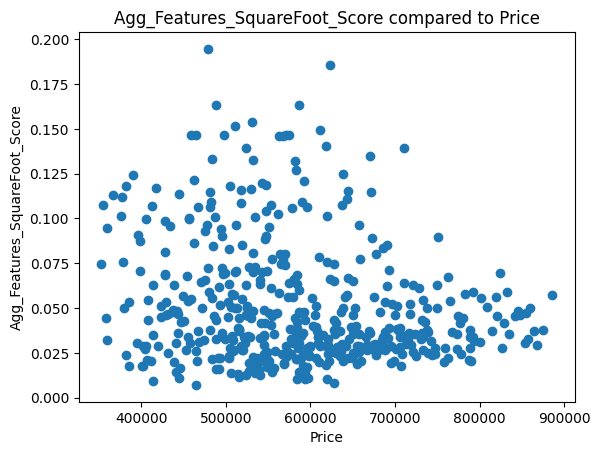

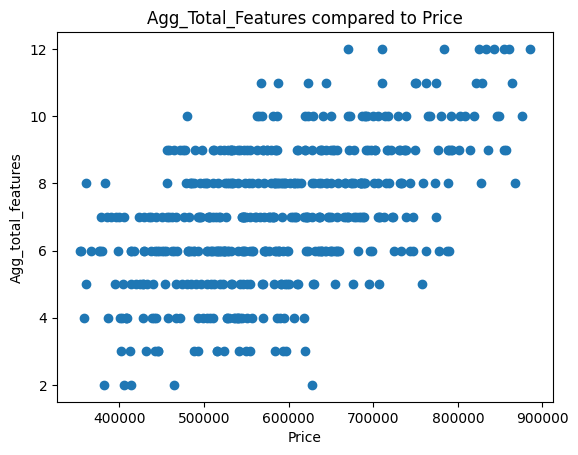

In [9]:
cleaned_house_df["Agg_Features_SquareFoot_Score"] =  cleaned_house_df['Agg_total_features'] /cleaned_house_df['Square_Feet'] 
plt.scatter(cleaned_house_df['Price'], cleaned_house_df['Agg_Features_SquareFoot_Score'])
plt.title("Agg_Features_SquareFoot_Score compared to Price")
plt.xlabel("Price")
plt.ylabel("Agg_Features_SquareFoot_Score")
plt.show()

plt.scatter(cleaned_house_df['Price'], cleaned_house_df['Agg_total_features'])
plt.title("Agg_Total_Features compared to Price")
plt.xlabel("Price")
plt.ylabel("Agg_total_features")
plt.show()

### Result Analysis

Looking at the above results, adding feature aggregation had a slight positive impacted the overall performance of the model. I attempted a few different combinations and aggregations, including aggregations of Location score and sq foot, locaton score and distance from center, and none seemed to have a significant positive impact. This tells me either that there is not a strong correlation between the features themselves and the final price (other than features and sq feet), or that my understanding of the domain is limited and I require a domain expert or further domain knowledge to find more complex aggregation that will yield better results 

The outliers removed showed the overall better, and overall was the most successful of the two method models. It showed clear improved over the base, and performed superior to all others models, except for the combination, which it's performance was quite comparable to. 

The final combination of the two results yield better results than the base model, but performed similarly to the outlier removed model.

The final testing done with the hidden test data performed similarly to the validation runs. This tells me that the model is quite stable on this dataset, as there is no major changes to the difference between the R2 scores of the models. Overall these models performed well on the data, and fits the dataset very well , as its  lowest R2 results was over 94%, which is very high.  


### References

New York City Airbnb open data. (2019). Kaggle. https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data 

pandas.DataFrame — pandas 3.0.1 documentation. (n.d.). https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html 

scikit-learn.LinearRegression — scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

cross_val_score -- scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

Python - Coefficient of Determination-R2 score - GeeksForGeeks https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/

train_test_split - scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

LocalOutlierFactor - scikit-learn 1.8.0 documentation https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html

Google Gemini, queries preformed: 

"correlation between square feet and location" (Used to develop more "Domain Knowledge on subject).

"Pandas how to fix 'TypeError: Invalid value 'invalid_string' for dtype 'int64'' when trying to inject a string into a numeric column?" (Used to find the .astype(object) workaround for the Data Type error test).

"How to find all duplicate rows based on a specific ID column in Pandas, making sure to include the original first occurrence in the mask?" (Used to discover the keep=False parameter for the Uniqueness error test).